# Train and evaluate the home-gateway autoencoder

## tl;dr

This is the authoritative training run for the committed development model. It
starts from the supplied synthetic monitoring CSV, removes its repeated rows,
builds normal-only 24-hour windows, trains the real Conv1D autoencoder for 30
epochs, exports the fully int8 model, evaluates its fixed threshold, and
regenerates the performance plots.

The evaluation compares held-out generated normal windows with deliberately
shifted engineering simulations. It demonstrates the implemented anomaly
mechanism; it does not estimate performance on future field participants.

## Context & Methods

The wearable measures PPG/SpO₂, temperature, and motion. Heart rate is derived
from PPG before the gateway receives the packet. The autoencoder sees 288
five-minute steps containing four normalized physiological features, four
quality values, and eight present/missing masks.

### Key assumptions

- Only rows marked `Normal` seed autoencoder training.
- The 60 generated subject identities are simulation groups, not real people.
- GalaxyPPG and BIDMC remain separate engineering references because neither
  contains the complete aligned gateway feature set.
- The validation split sets the threshold; the test split remains held out.

In [1]:
from pathlib import Path
import json
import os
import sys

os.environ.setdefault("MPLBACKEND", "Agg")
repo_root = Path.cwd().resolve()
if repo_root.name == "notebooks":
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root / "src"))

from IPython.display import Image, Markdown, display
from home_health_monitor.datasets.audit import audit_synthetic
from home_health_monitor.datasets.development import (
    build_development_corpus,
    load_supplied_monitoring_rows,
    write_normal_windows,
)
from home_health_monitor.gateway.training import train_and_export
from home_health_monitor.reporting import performance_summary, render_development_plots

supplied_csv = repo_root / "notebooks" / "data" / "supplied-monitoring.csv"
evidence_path = repo_root / "models" / "development-demo" / "data-evidence.json"
model_directory = repo_root / "models" / "development-demo"
plot_directory = repo_root / "docs" / "assets" / "development-demo"
work_directory = repo_root / "notebooks" / ".work"
normal_windows_path = work_directory / "development-normal-windows.jsonl"
work_directory.mkdir(parents=True, exist_ok=True)

SEED = 42
SUBJECTS = 60
WINDOWS_PER_SUBJECT = 4
EPOCHS = 30
BATCH_SIZE = 16

print(f"Repository: {repo_root}")
print(f"Training source: {supplied_csv.relative_to(repo_root)}")
print(f"Model output: {model_directory.relative_to(repo_root)}")

Repository: /Users/sam/Documents/home-health-monitor
Training source: notebooks/data/supplied-monitoring.csv
Model output: models/development-demo


## Data

In [2]:
audit = audit_synthetic(supplied_csv)
supplied_rows = load_supplied_monitoring_rows(supplied_csv)
normal_seed_rows = [row for row in supplied_rows if row.is_normal]
evidence = json.loads(evidence_path.read_text(encoding="utf-8"))

data_check = {
    "supplied_rows": audit.total_rows,
    "supplied_unique_rows": audit.unique_rows,
    "duplicate_rows_removed": audit.duplicate_rows,
    "distinct_normal_seed_rows": len(normal_seed_rows),
    "reviewed_sources": [source["dataset"] for source in evidence["sources"]],
}
print(json.dumps(data_check, indent=2))

assert audit.total_rows == 612
assert audit.unique_rows == 36
assert len(normal_seed_rows) == 11

{
  "supplied_rows": 612,
  "supplied_unique_rows": 36,
  "duplicate_rows_removed": 576,
  "distinct_normal_seed_rows": 11,
  "reviewed_sources": [
    "supplied_monitoring_fall_csv",
    "GalaxyPPG",
    "BIDMC_PPG_and_Respiration"
  ]
}


In [3]:
corpus = build_development_corpus(
    supplied_rows,
    subject_count=SUBJECTS,
    windows_per_subject=WINDOWS_PER_SUBJECT,
    seed=SEED,
)
write_normal_windows(corpus, normal_windows_path)

corpus_check = {
    "virtual_subjects": len({window.subject_id for window in corpus.normal_windows}),
    "normal_training_windows": len(corpus.normal_windows),
    "withheld_controlled_anomaly_windows": len(corpus.simulated_anomaly_windows),
    "steps_per_window": len(corpus.normal_windows[0].values),
}
print(json.dumps(corpus_check, indent=2))

{
  "virtual_subjects": 60,
  "normal_training_windows": 240,
  "withheld_controlled_anomaly_windows": 240,
  "steps_per_window": 288
}


## Results

### Train and export the actual model

This cell performs the training. It is not a placeholder: it fits the Keras
model, converts it to a fully integer TFLite model, runs quantized validation
and test inference, chooses thresholds, verifies the exported runtime contract,
and writes the committed artifacts.

In [4]:
metadata = train_and_export(
    normal_windows_path,
    model_directory,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    seed=SEED,
    artifact_role="development_demo",
)

print(json.dumps({
    "model_id": metadata["model_id"],
    "model_sha256": metadata["model_sha256"],
    "model_size_bytes": (model_directory / "model.tflite").stat().st_size,
    "persistent_threshold": metadata["thresholds"]["persistent_error"],
    "severe_threshold": metadata["thresholds"]["severe_error"],
    "split": metadata["dataset"],
}, indent=2))

Epoch 1/30


11/11 - 1s - 96ms/step - loss: 0.2468 - val_loss: 0.2379


Epoch 2/30


11/11 - 0s - 5ms/step - loss: 0.2268 - val_loss: 0.2108


Epoch 3/30


...

INFO:tensorflow:Assets written to: /var/folders/l7/m3wgz92x6vj1gkr9lwh0893c0000gq/T/tmpu53mze1w/assets


Saved artifact at '/var/folders/l7/m3wgz92x6vj1gkr9lwh0893c0000gq/T/tmpu53mze1w'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 288, 16), dtype=tf.float32, name='window')
Output Type:
  TensorSpec(shape=(None, 288, 16), dtype=tf.float32, name=None)
Captures:
  4865626512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4865627664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4865626320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4865626128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4865627088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4865625744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4865626896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4865628240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4865626704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4865629584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4865628624: TensorSpec(s

/Users/sam/Documents/home-health-monitor/.venv-train/lib/python3.12/site-packages/tensorflow/lite/python/convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


{
  "model_id": "gateway-ae-cc9b07502845",
  "model_sha256": "19bac53bb029fe82808e7a032d1a8f6d048a2aea2993d1495935834f3dc97ac0",
  "model_size_bytes": 18384,
  "persistent_threshold": 0.014289190666750074,
  "severe_threshold": 0.028578381333500148,
  "split": {
    "normal_only": true,
    "windows": 240,
    "train_windows": 168,
    "validation_windows": 36,
    "test_windows": 36,
    "train_subjects": [
      "development-001",
      "development-002",
      "development-003",
      "development-005",
      "development-006",
      "development-007",
      "development-008",
      "development-009",
      "development-011",
      "development-013",
      "development-014",
      "development-015",
      "development-016",
      "development-018",
      "development-019",
      "development-023",
      "development-025",
      "development-026",
      "development-027",
      "development-028",
      "development-029",
      "development-030",
      "development-033",
      "develo

W0000 00:00:1788823583.844559 2340183 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1788823583.844575 2340183 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1788823583.845030 2340183 reader.cc:83] Reading SavedModel from: /var/folders/l7/m3wgz92x6vj1gkr9lwh0893c0000gq/T/tmpu53mze1w
I0000 00:00:1788823583.845547 2340183 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1788823583.845552 2340183 reader.cc:147] Reading SavedModel debug info (if present) from: /var/folders/l7/m3wgz92x6vj1gkr9lwh0893c0000gq/T/tmpu53mze1w
I0000 00:00:1788823583.849611 2340183 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
I0000 00:00:1788823583.850240 2340183 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1788823583.872018 2340183 loader.cc:220] Running initialization op on SavedModel bundle at path: /var/folders/l7/m3wgz92x6vj1gkr9lwh0893c0000gq/T/tmpu53mze1w
I0000 00:00:1788823583.880172 2340183 lo

### Calculate fixed-threshold performance

In [5]:
training_report_path = model_directory / "training-report.json"
training_report = json.loads(training_report_path.read_text(encoding="utf-8"))
performance = performance_summary(training_report)
performance_path = model_directory / "performance-summary.json"
performance_path.write_text(
    json.dumps(performance, indent=2, sort_keys=True) + "\n",
    encoding="utf-8",
)

print(json.dumps(performance, indent=2))

{
  "artifact_role": "development_demo",
  "model_id": "gateway-ae-cc9b07502845",
  "evaluation_scope": "held_out_generated_normal_vs_controlled_simulation",
  "binary": {
    "threshold": 0.014289190666750074,
    "confusion": {
      "tn": 32,
      "fp": 4,
      "fn": 0,
      "tp": 36
    },
    "accuracy": 0.9444444444444444,
    "precision": 0.9,
    "recall": 1.0,
    "specificity": 0.8888888888888888,
    "balanced_accuracy": 0.9444444444444444,
    "f1": 0.9473684210526316,
    "normal_windows": 36,
    "controlled_anomaly_windows": 36
  },
  "by_scenario": {
    "sustained_high_heart_rate": {
      "count": 9,
      "mean_score": 0.1937397470076879,
      "minimum_score": 0.1604146510362625,
      "maximum_score": 0.24738377332687378,
      "detection_fraction": 1.0
    },
    "sustained_high_temperature": {
      "count": 9,
      "mean_score": 0.323247018787596,
      "minimum_score": 0.27751946449279785,
      "maximum_score": 0.3867357671260834,
      "detection_fraction

### Generate and inspect the plots

In [6]:
plot_paths = render_development_plots(
    evidence_path,
    training_report_path,
    plot_directory,
)
print("Generated plots:")
for path in plot_paths:
    print(f"- {path.relative_to(repo_root)}")

Generated plots:
- docs/assets/development-demo/dataset-feature-availability.png
- docs/assets/development-demo/autoencoder-confusion-matrix.png
- docs/assets/development-demo/autoencoder-scenario-performance.png
- docs/assets/development-demo/autoencoder-training-loss.png
- docs/assets/development-demo/autoencoder-score-distribution.png
- docs/assets/development-demo/autoencoder-reconstruction-example.png


#### Dataset Feature Availability

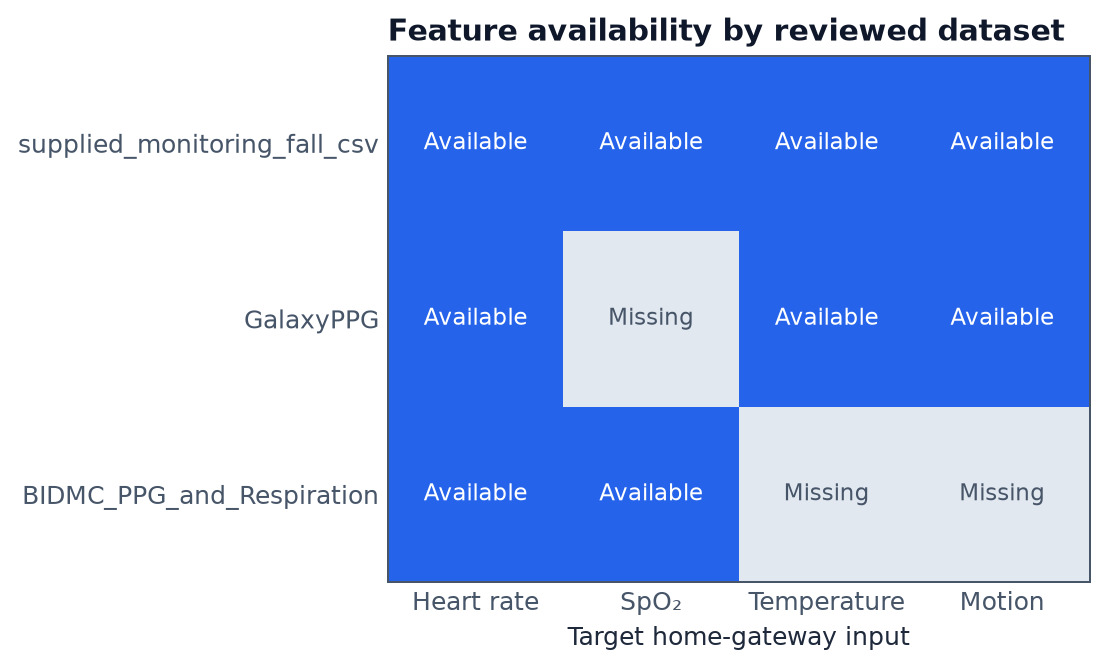

#### Autoencoder Confusion Matrix

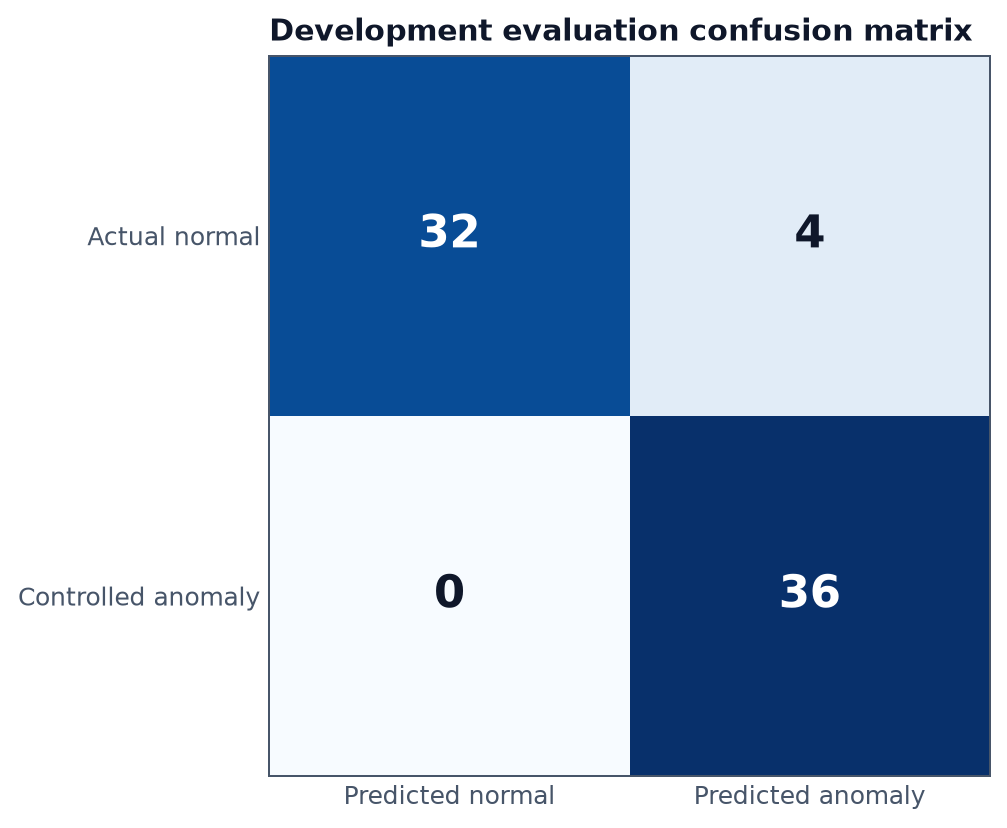

#### Autoencoder Scenario Performance

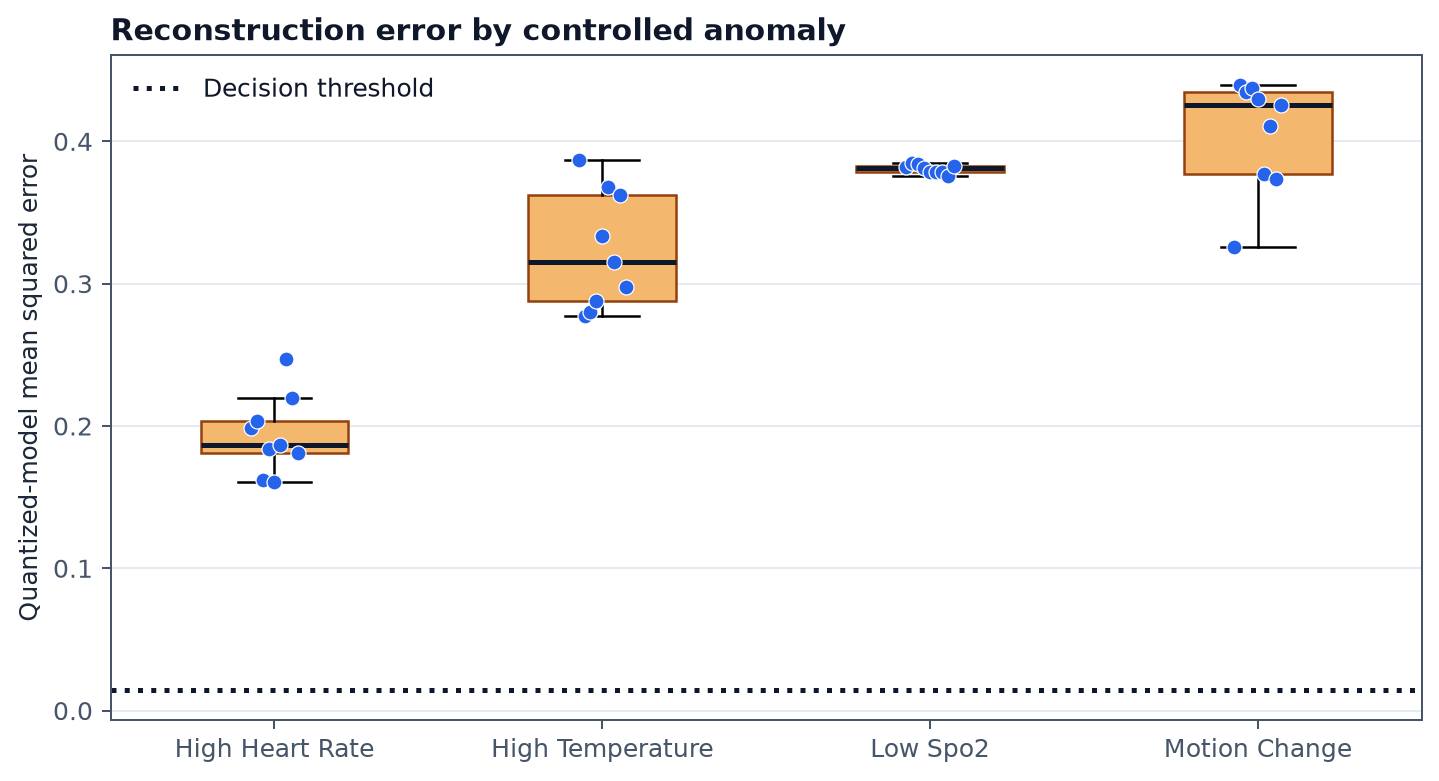

#### Autoencoder Training Loss

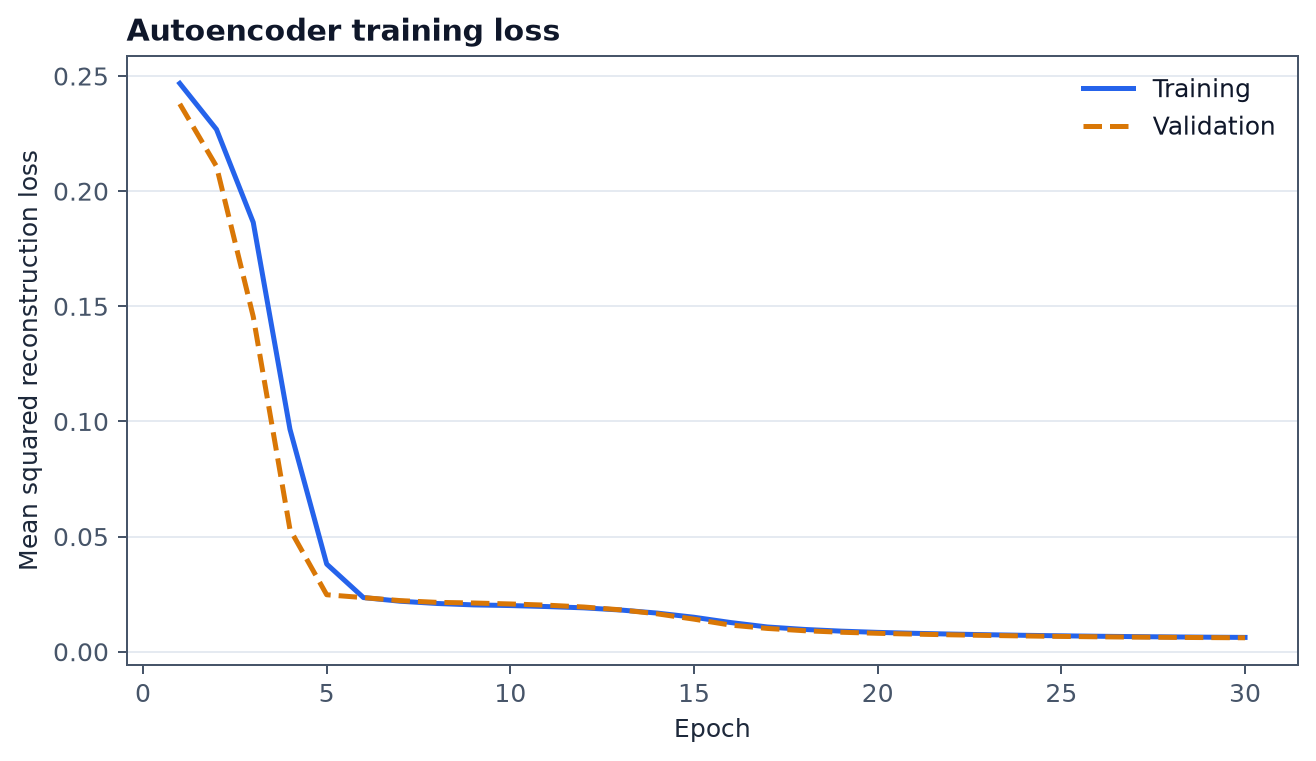

#### Autoencoder Score Distribution

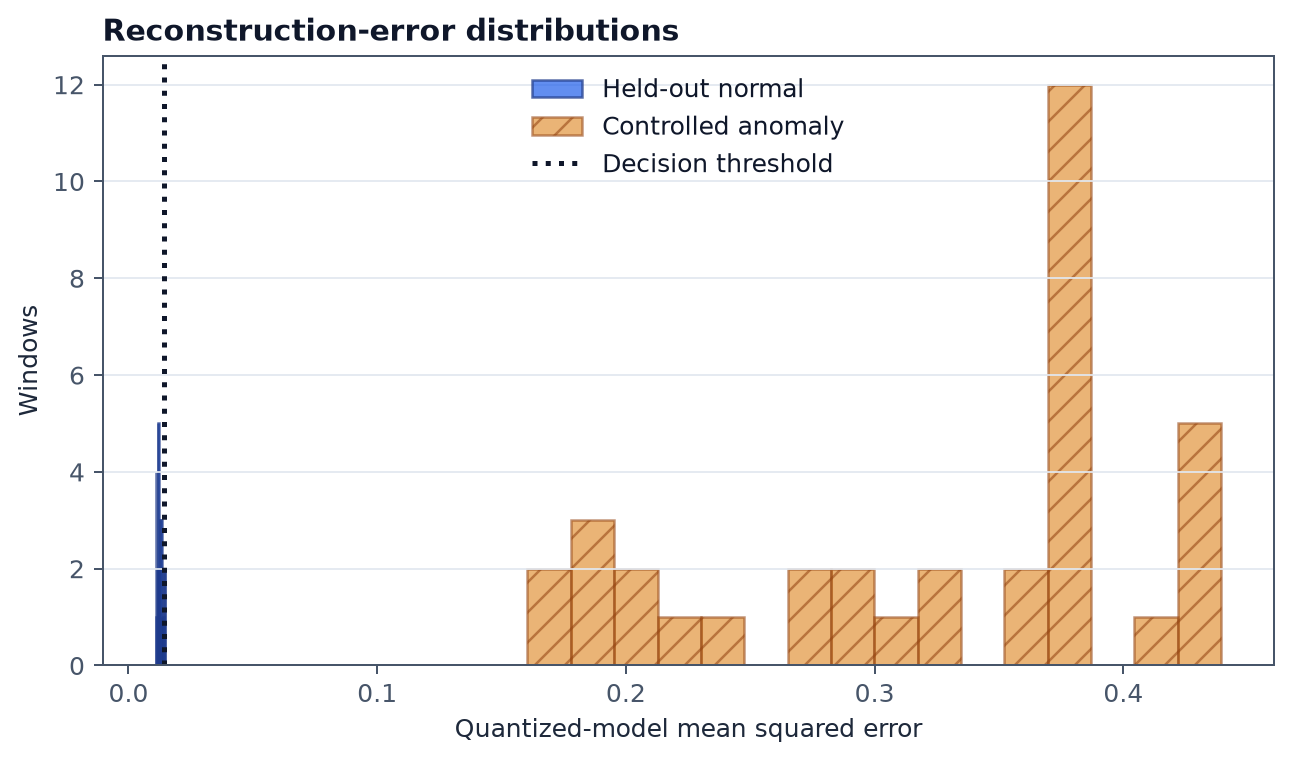

#### Autoencoder Reconstruction Example

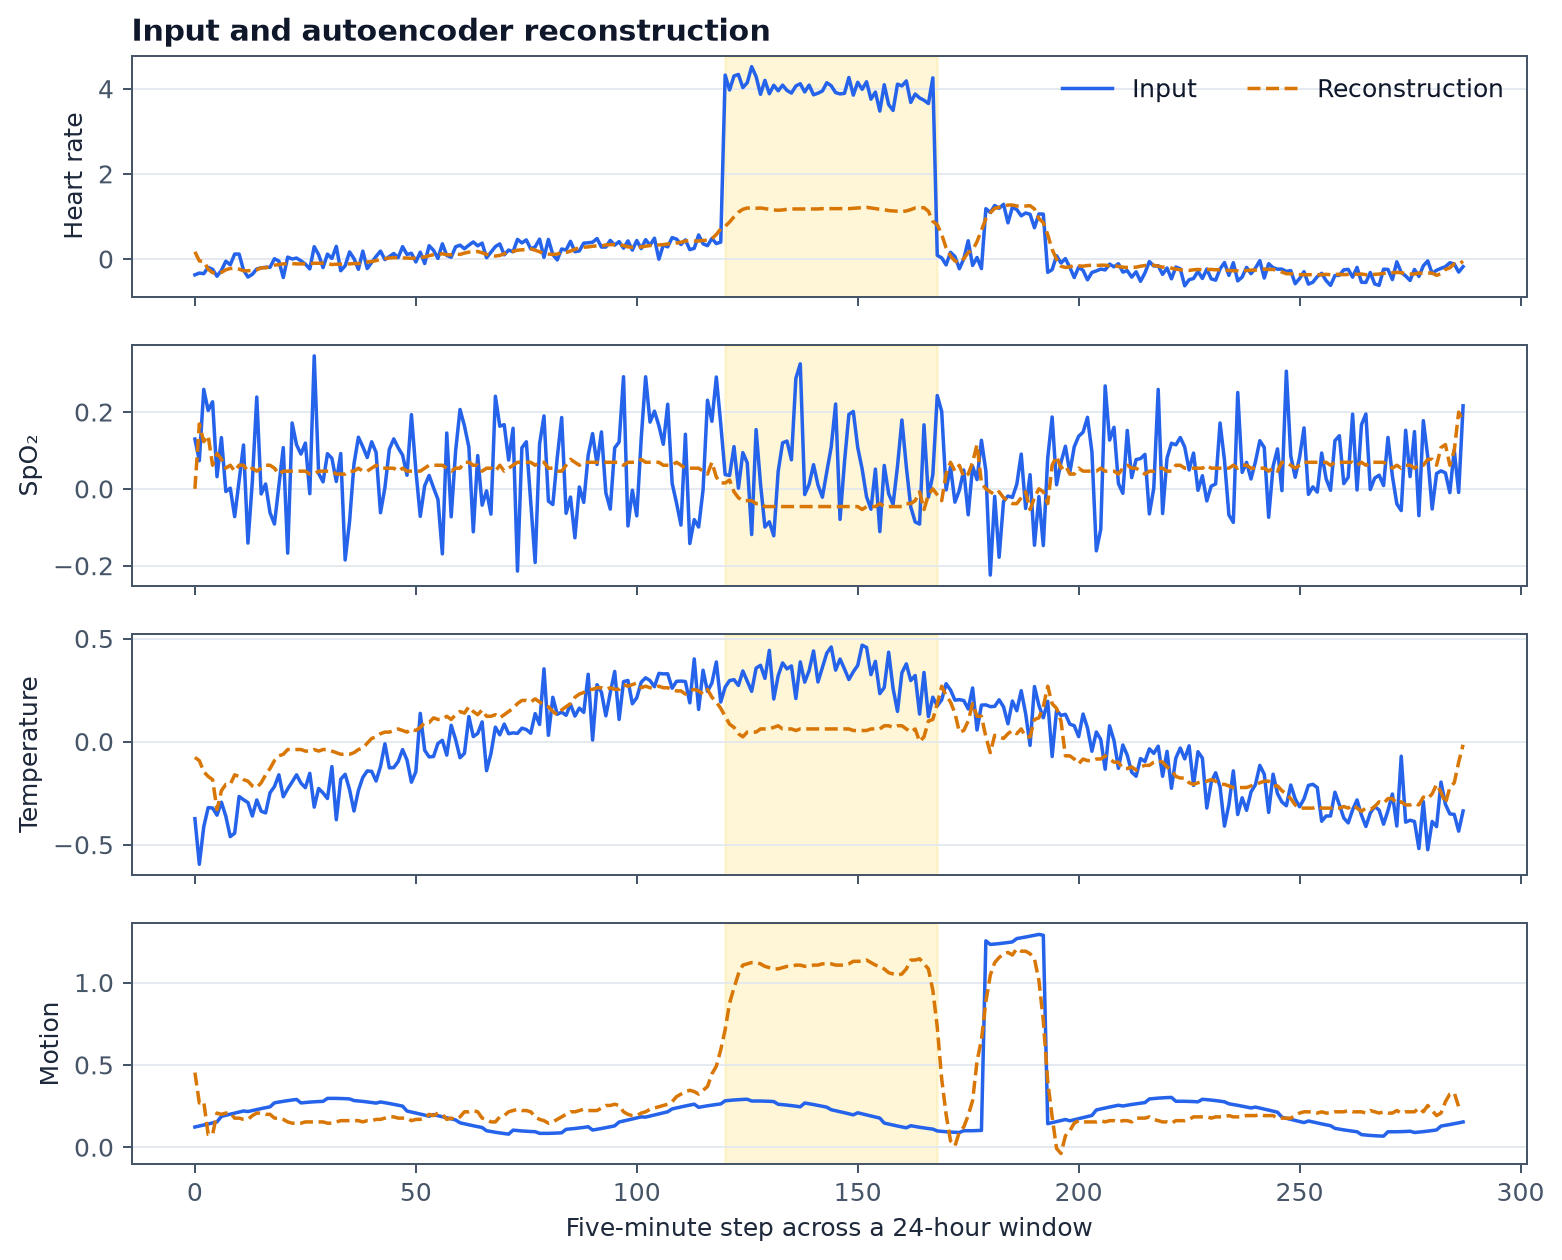

In [7]:
for plot_path in plot_paths:
    display(Markdown(f"#### {plot_path.stem.replace('-', ' ').title()}"))
    display(Image(filename=str(plot_path), width=900))

## Takeaways

- Training and validation reconstruction loss should fall together. A wide
  separation would indicate that the model is memorizing the generated train
  split.
- The confusion matrix and reported metrics apply only to held-out generated
  normals versus controlled sustained shifts.
- Per-scenario scores show whether the mechanism reacts to high heart rate,
  low SpO₂, elevated temperature, and changed motion patterns.
- The reconstruction plot explains the decision: a normal-only autoencoder
  rebuilds a normal-like pattern, so an unusual input leaves a large residual.
- The development artifact is ready for Pi integration and resource testing.
  The same notebook should be rerun with windows prepared from the exact target
  wearable before selecting a field model.